# Post-Cavity Experiment Notebook

Comprehensive characterization using the **qubox_v2 v3** modular experiment API
with the unified `run() -> analyze() -> plot()` workflow.

**Sections:**
1. Initialization
2. OPX/Octave Mixer Calibration
3. Readout Characterization
4. Qubit Characterization
5. Pulse Calibration
6. Readout Calibration
7. SPA Benchmarking
8. Storage Cavity
9. Quantum State Tomography
10. Utility: Continuous-Wave Output

In [1]:
import sys
import numpy as np

sys.path.insert(0, r"E:\qubox")

from qualang_tools.units import unit

from qubox_v2.experiments.session import SessionManager
from qubox_v2.experiments import (
    # Spectroscopy
    ResonatorSpectroscopy,
    ResonatorPowerSpectroscopy,
    ResonatorSpectroscopyX180,
    ReadoutTrace,
    QubitSpectroscopy,
    QubitSpectroscopyEF,
    # Time domain
    PowerRabi,
    TemporalRabi,
    T1Relaxation,
    T2Ramsey,
    T2Echo,
    # Calibration
    IQBlob,
    ReadoutGEDiscrimination,
    ReadoutWeightsOptimization,
    ReadoutButterflyMeasurement,
    CalibrateReadoutFull,
    AllXY,
    DRAGCalibration,
    QubitPulseTrain,
    RandomizedBenchmarking,
    # Cavity / Fock
    StorageSpectroscopy,
    NumSplittingSpectroscopy,
    StorageChiRamsey,
    FockResolvedSpectroscopy,
    FockResolvedT1,
    FockResolvedRamsey,
    FockResolvedPowerRabi,
    # Tomography
    QubitStateTomography,
    StorageWignerTomography,
    SNAPOptimization,
    # SPA
    SPAFluxOptimization,
    SPAPumpFrequencyOptimization,
)
from qubox_v2.experiments.calibration import ReadoutConfig

u = unit()

2026-02-22 18:16:44,227 - qm - INFO     - Starting session: 11881f36-014a-41ee-a4a3-f721f0234635


## 1. Initialization

Create a `SessionManager` which wires up hardware, pulses, calibration,
and device connections. All experiment classes accept it as their context.

In [3]:
experiment_path = r"E:\qubox\seq_1_device"

session = SessionManager(
    experiment_path,
    qop_ip="10.157.36.68",
    cluster_name="Cluster_2",
)

# Open QM connection and build element table (required before hardware ops)
session.open()

attr = session.attributes
print(f"Resonator: {attr.ro_fq / 1e9:.4f} GHz")
print(f"Qubit:     {attr.qb_fq / 1e9:.4f} GHz")
print(f"Storage:   {attr.st_fq / 1e9:.4f} GHz")

# Uncomment to run in simulation mode:
# session.hw.set_exec_mode("simulate")

[INFO] 2026-02-22 18:17:08,059 qubox.experiments.session: SessionManager initialising at E:\qubox\seq_1_device
2026-02-22 18:17:11,813 - qm - INFO     - Performing health check
2026-02-22 18:17:11,818 - qm - INFO     - Health check passed
[INFO] 2026-02-22 18:17:11,830 qubox.calibration.store: Loading calibration from E:\qubox\seq_1_device\config\calibration.json


Deprecated cqed_params keys loaded for backward compatibility: ['ro_therm_clks', 'qb_therm_clks', 'st_therm_clks', 'b_coherent_amp', 'b_coherent_len', 'b_alpha']


[INFO] 2026-02-22 18:17:14,516 qubox.experiments.session: SessionManager ready.
[INFO] 2026-02-22 18:17:16,144 qubox.experiments.session: Loaded measureMacro state from E:\qubox\seq_1_device\config\measureConfig.json
[INFO] 2026-02-22 18:17:16,145 qubox.experiments.session: Runtime element validation: available=['qubit', 'qubit2', 'resonator', 'storage']
Resonator: 8.5962 GHz
Qubit:     6.1504 GHz
Storage:   5.2409 GHz


### 1.0b Session Snapshot & Artifact Setup

Build an immutable `SessionState` snapshot from the config directory. This freezes
all source-of-truth files (hardware, calibration, pulses) into a hash-keyed
record for reproducibility. `ArtifactManager` stores all session outputs under
this build hash.

In [ ]:
from pathlib import Path
from qubox_v2.core.session_state import SessionState
from qubox_v2.core.artifact_manager import ArtifactManager

config_dir = Path(experiment_path) / "config"
ss = SessionState.from_config_dir(config_dir)
am = ArtifactManager(experiment_path, ss.build_hash)

# Persist immutable snapshot for reproducibility
am.save_session_state(ss.to_dict())

print(ss.summary())
print(f"\nArtifacts root: {am.root}")

### 1.1 Preflight Check

Run a preflight validation to catch common configuration problems before experiments.

In [ ]:
from qubox_v2.core.preflight import preflight_check
from qubox_v2.core.artifacts import save_config_snapshot

# Run preflight validation
report = preflight_check(session)

if report["all_ok"]:
    print("All preflight checks PASSED.")
else:
    print("PREFLIGHT FAILURES:")
    for err in report["errors"]:
        print(f"  - {err}")

if report["warnings"]:
    print("Warnings:")
    for w in report["warnings"]:
        print(f"  - {w}")

# Save initial config snapshot for reproducibility
snapshot_path = save_config_snapshot(session, tag="session_open")
print(f"\nConfig snapshot saved to: {snapshot_path}")

# Schema validation (declarative architecture)
from qubox_v2.core.schemas import validate_config_dir

schema_results = validate_config_dir(config_dir)
print("\nSchema validation:")
for r in schema_results:
    status = "PASS" if r.valid else "FAIL"
    print(f"  {status} v={r.version}")
    for e in r.errors:
        print(f"    ERROR: {e}")
    for w in r.warnings:
        print(f"    WARN: {w}")

### 1.2 Runtime Readout Operation Override

Override which element/operation `measureMacro` uses **at runtime** (no manual hardware JSON edits).
This affects subsequent readout-based experiments in this session.

In [ ]:
# --- User override inputs ---
READOUT_OVERRIDE_ELEMENT = attr.ro_el      # e.g. "resonator", "storage"
READOUT_OVERRIDE_OP = "readout"            # e.g. "readout", "readout_short"
READOUT_OVERRIDE_WEIGHTS = None             # None -> default [cos,sin] / [minus_sin,cos]
READOUT_OVERRIDE_DEMOD = "dual_demod.full"  # currently supports "dual_demod.full"
READOUT_OVERRIDE_THRESHOLD = None           # optional discriminator threshold
READOUT_OVERRIDE_WEIGHT_LEN = None          # optional demod integration length (ns)

override_info = session.override_readout_operation(
    element=READOUT_OVERRIDE_ELEMENT,
    operation=READOUT_OVERRIDE_OP,
    weights=READOUT_OVERRIDE_WEIGHTS,
    demod=READOUT_OVERRIDE_DEMOD,
    threshold=READOUT_OVERRIDE_THRESHOLD,
    weight_len=READOUT_OVERRIDE_WEIGHT_LEN,
    apply_to_attributes=True,
    persist_measure_config=True,
    drive_frequency=attr.ro_fq,
)

print("Readout override applied:")
print(f"  element:            {override_info['element']}")
print(f"  operation:          {override_info['operation']}")
print(f"  pulse:              {override_info['pulse']}")
print(f"  attributes.ro_el:   {override_info['attributes_ro_el']}")
print(f"  QM mapping:         {override_info['qm_config_entry']}")
print(f"  measureConfig path: {override_info['measure_config_path']}")

## 2. OPX/Octave Mixer Calibration

Calibrate IQ mixer offsets (DC offset, gain imbalance, phase imbalance) for
each element. Run this before any measurements to ensure clean signal generation.

### 2.0 Manual Calibration UX Controls

Configure logging, scan bounds/grid, SA settings, and sideband objective for manual IQ calibration.
These parameters are passed directly into `MixerCalibrationConfig`.

In [ ]:
# -------- Notebook-level UX toggles --------
QUIET_QM_LOGS = True      # suppress qm INFO compile/execute spam inside manual loops
LIVE_PLOTS = True         # live heatmaps/history while scanning/minimizing
LIVE_PLOT_EVERY = 1       # update cadence (iterations)

# -------- Scan bounds / grid --------
# Stage A (DC offset): coarse + fine 2D grid
DC_COARSE_RANGE = 0.10
DC_COARSE_N = 11
DC_FINE_RANGE = 0.02
DC_FINE_N = 11

# Stage B (IQ correction): coarse + fine 2D grid
IQ_GAIN_RANGE = 0.10
IQ_PHASE_RANGE = 0.20
IQ_COARSE_N = 11
IQ_FINE_GAIN_RANGE = 0.02
IQ_FINE_PHASE_RANGE = 0.04
IQ_FINE_N = 11

# Minimizer settings
MIN_MAXITER = 60
MIN_XTOL = 1e-4

# -------- Spectrum analyzer settings --------
SA_SPAN_HZ = 2e6
SA_RBW = 10e3
SA_VBW = 10e3
SA_LEVEL_DBM = 0.0
SA_AVG = 1
SA_SETTLE_S = 0.0

# Optional SA driver kwargs (only if your SA driver supports them)
# Examples: attenuation, detector, ref_level, preamp
SA_EXTRA_CONFIG = {
    # "attenuation": 10,
    # "detector": "peak",
}

# -------- Sideband targeting objective --------
# sideband='usb' means desired tone is LO+IF, image is LO-IF
# sideband='lsb' means desired tone is LO-IF, image is LO+IF
SIDEBAND = "lsb"
OBJECTIVE_MODE = "weighted_sum"   # 'weighted_sum' or 'ratio_db'
W_CARRIER = 1.0
W_IMAGE = 1.0
W_TARGET = 1.0

print("Manual calibration controls set.")

In [ ]:
hw = session.hw

# Gather elements and their frequencies
elements = [attr.ro_el, attr.qb_el, attr.st_el]
el_los = hw.get_element_lo(elements)
el_ifs = [hw.calculate_el_if_fq(el, fq)
          for el, fq in zip(elements, [attr.ro_fq, attr.qb_fq, attr.st_fq])]

print("Mixer calibration targets:")
for el, lo, if_fq in zip(elements, el_los, el_ifs):
    print(f"  {el:20s}  LO={lo/1e9:.4f} GHz  IF={if_fq/1e6:.2f} MHz")

# --- Manual IQ mixer calibration via SA124B (requires SA connected) ---
from qubox_v2.calibration import MixerCalibrationConfig, SAMeasurementHelper

cfg = MixerCalibrationConfig(
    # SA settings
    sa_span_hz=SA_SPAN_HZ,
    sa_rbw=SA_RBW,
    sa_vbw=SA_VBW,
    sa_level=SA_LEVEL_DBM,
    sa_avg=SA_AVG,
    sa_settle=SA_SETTLE_S,
    sa_extra_config=SA_EXTRA_CONFIG,

    # DC scan bounds/grid
    dc_coarse_range=DC_COARSE_RANGE,
    dc_coarse_n=DC_COARSE_N,
    dc_fine_range=DC_FINE_RANGE,
    dc_fine_n=DC_FINE_N,

    # IQ scan bounds/grid
    iq_gain_range=IQ_GAIN_RANGE,
    iq_phase_range=IQ_PHASE_RANGE,
    iq_coarse_n=IQ_COARSE_N,
    iq_fine_range_gain=IQ_FINE_GAIN_RANGE,
    iq_fine_range_phase=IQ_FINE_PHASE_RANGE,
    iq_fine_n=IQ_FINE_N,

    # Minimizer
    minimizer_maxiter=MIN_MAXITER,
    minimizer_xtol=MIN_XTOL,

    # UX controls
    quiet_qm_logs=QUIET_QM_LOGS,
    live_plot=LIVE_PLOTS,
    live_plot_every=LIVE_PLOT_EVERY,

    # Explicit sideband objective
    sideband=SIDEBAND,
    objective_mode=OBJECTIVE_MODE,
    w_carrier=W_CARRIER,
    w_image=W_IMAGE,
    w_target=W_TARGET,
)

target_el = "qubit"
idx = elements.index(target_el)
target_lo = float(el_los[idx])
target_if = float(el_ifs[idx])

# Baseline SA measurement before calibration
sa_dev = session.devices.get("sa124b")
sa_helper = SAMeasurementHelper(sa_dev, cfg)
before = sa_helper.measure_tones(target_lo, target_if)

# Run calibration (choose one method)
result = hw.calibrate_element(
    el=target_el,
    method="manual_minimizer",
    mixer_cal_config=cfg,
    save_to_db=False,
)

# Post-calibration SA measurement
after = sa_helper.measure_tones(target_lo, target_if)

print("\nManual calibration complete.")

# Quantitative mixer metrics summary
metrics_rows = [
    ("Target sideband power (dBm)", before["P_des_dBm"], after["P_des_dBm"], after["P_des_dBm"] - before["P_des_dBm"]),
    ("LO leakage power (dBm)", before["P_LO_dBm"], after["P_LO_dBm"], after["P_LO_dBm"] - before["P_LO_dBm"]),
    ("Image sideband power (dBm)", before["P_img_dBm"], after["P_img_dBm"], after["P_img_dBm"] - before["P_img_dBm"]),
    ("Target/LO (dBc)", before["LO_leak_dBc"], after["LO_leak_dBc"], after["LO_leak_dBc"] - before["LO_leak_dBc"]),
    ("Target/Image (dBc)", before["IRR_dBc"], after["IRR_dBc"], after["IRR_dBc"] - before["IRR_dBc"]),
]

print("\nMixer calibration metrics (before -> after):")
print(f"{'Metric':32s} {'Before':>10s} {'After':>10s} {'Delta':>10s}")
for name, b, a, d in metrics_rows:
    print(f"{name:32s} {b:10.2f} {a:10.2f} {d:10.2f}")

import matplotlib.pyplot as plt
labels = [r[0] for r in metrics_rows]
before_vals = [r[1] for r in metrics_rows]
after_vals = [r[2] for r in metrics_rows]

x = np.arange(len(labels))
w = 0.38
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - w/2, before_vals, width=w, label="Before")
ax.bar(x + w/2, after_vals, width=w, label="After")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_title("Mixer Calibration Metrics: Before vs After")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Readout Characterization

### 3.1 Readout Trace

Acquire raw ADC traces to verify readout signal level and timing.

In [ ]:
trace = ReadoutTrace(session)
result = trace.run(attr.ro_fq, n_avg=10000)

analysis = trace.analyze(result)
trace.plot(analysis)
print(analysis.metrics)

### 3.2 Resonator Spectroscopy

Sweep readout frequency to locate resonator resonance. The `analyze()` method
fits a Lorentzian and extracts `f0` and `kappa`.

In [ ]:
spec = ResonatorSpectroscopy(session)
result = spec.run(
    "readout",
    rf_begin=8560 * u.MHz,
    rf_end=8640 * u.MHz,
    df=200 * u.kHz,
    n_avg=10000,
)

analysis = spec.analyze(result, update_calibration=True)
spec.plot(analysis)
print(f"f0 = {analysis.metrics['f0'] / 1e6:.4f} MHz")
print(f"kappa = {analysis.metrics['kappa'] / 1e3:.1f} kHz")

### 3.3 Resonator Power Spectroscopy

2D sweep of readout frequency vs gain to find optimal readout power.

In [ ]:
pspec = ResonatorPowerSpectroscopy(session)
result = pspec.run(
    "readout",
    rf_begin=8590 * u.MHz,
    rf_end=8600 * u.MHz,
    df=50 * u.kHz,
    g_min=0.01,
    g_max=1.9,
    N_a=20,
    n_avg=5000,
)

analysis = pspec.analyze(result)
pspec.plot(analysis)
print(f"Optimal gain: {analysis.metrics.get('optimal_gain', 'N/A')}")
print(f"Optimal freq: {analysis.metrics.get('optimal_freq', 'N/A')}")

### 3.4 Resonator Spectroscopy with X180

Measure resonator with ground and excited qubit states to extract
dispersive shift chi.

In [ ]:
spec_x180 = ResonatorSpectroscopyX180(session)
result = spec_x180.run(
    rf_begin=8560 * u.MHz,
    rf_end=8640 * u.MHz,
    df=200 * u.kHz,
    n_avg=10000,
)

analysis = spec_x180.analyze(result, update_calibration=True)
spec_x180.plot(analysis)
print(f"f0_g = {analysis.metrics.get('f0_g', 0) / 1e6:.4f} MHz")
print(f"f0_e = {analysis.metrics.get('f0_e', 0) / 1e6:.4f} MHz")
print(f"chi = {analysis.metrics.get('chi', 0) / 1e3:.1f} kHz")

## 4. Qubit Characterization

### 4.1 Qubit Spectroscopy

Sweep qubit drive frequency to locate the qubit transition.

In [ ]:
qb_spec = QubitSpectroscopy(session)
result = qb_spec.run(
    "saturation",
    rf_begin=6130 * u.MHz,
    rf_end=6170 * u.MHz,
    df=500 * u.kHz,
    qb_gain=1.0,
    qb_len=1000,
    n_avg=1000,
)

analysis = qb_spec.analyze(result, update_calibration=True)
qb_spec.plot(analysis)
print(f"f0 = {analysis.metrics['f0'] / 1e6:.4f} MHz")

### 4.2 Power Rabi

Sweep qubit drive amplitude to calibrate the pi pulse gain.

2026-02-22 18:08:11,704 - qm - INFO     - Sending program to QOP for compilation
2026-02-22 18:08:11,772 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 4999/5000 [00:30<00:00, 162.62it/s]

[INFO] 2026-02-22 18:08:42,570 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622593028
No errors
[INFO] 2026-02-22 18:08:42,598 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-22 18:08:42,600 qubox.experiments.session: Output saved to E:\qubox\seq_1_device\data\powerRabi_20260222_180842.npz


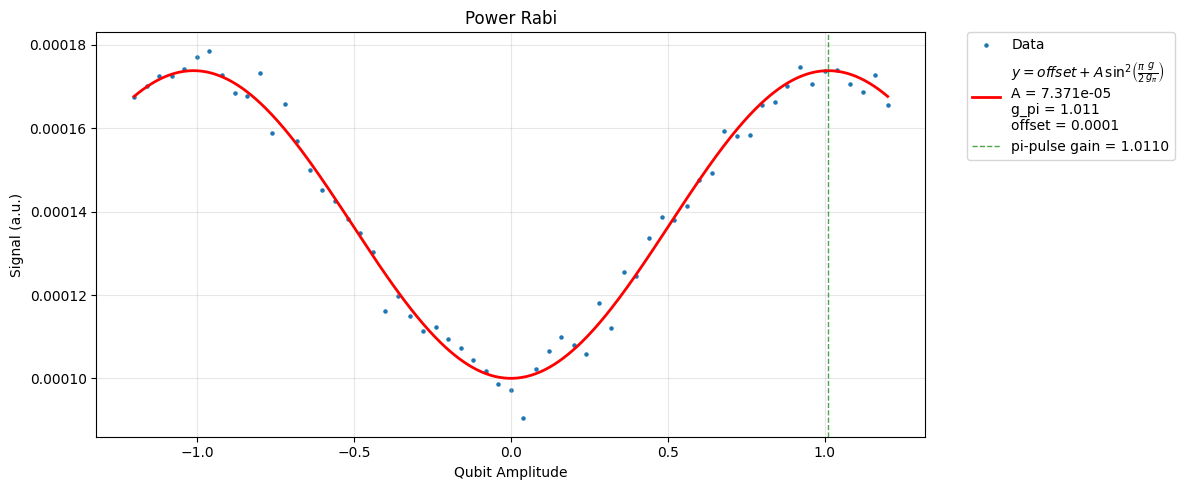

g_pi (ref_r180) = 1.010950


In [7]:
rabi = PowerRabi(session)
result = rabi.run(
    max_gain=1.2,
    dg=0.04,
    op="ref_r180",
    n_avg=5000,
)

analysis = rabi.analyze(result, update_calibration=False, p0=[0.0001, 1, 0])
rabi.plot(analysis)
rabi_g_pi = float(analysis.metrics.get("g_pi", 1.0))
print(f"g_pi (ref_r180) = {rabi_g_pi:.6f}")

### 4.2b Safe Calibration Commit for `ref_r180`

Uses the `CalibrationStateMachine` lifecycle to validate and commit the
Power Rabi result. The state machine enforces:

1. **Quality gates** â€” RÂ², amplitude bounds, residual check, monotonicity
2. **Explicit patch** â€” `CalibrationPatch` records exactly what changed
3. **Audit trail** â€” full state history for reproducibility

If validation fails, the candidate is saved as an artifact (not committed).

In [ ]:
from qubox_v2.pulses.manager import BASE_AMPLITUDE
from qubox_v2.calibration.state_machine import (
    CalibrationStateMachine, CalibrationState,
    CalibrationPatch, PatchValidation,
)

# --- State machine: Power Rabi â†’ ref_r180 commit ---
sm_rabi = CalibrationStateMachine(experiment="power_rabi")
sm_rabi.transition(CalibrationState.CONFIGURED)
sm_rabi.transition(CalibrationState.ACQUIRING)   # Acquisition already done in 4.2
sm_rabi.transition(CalibrationState.ACQUIRED)
sm_rabi.transition(CalibrationState.ANALYZING)

# Acceptance criteria
MIN_R2 = 0.80
GPI_MIN = 0.01
GPI_MAX = 2.0
MAX_REL_RESIDUAL = 0.25
MONOTONIC_WINDOW = 3

fit = analysis.fit
g_pi = analysis.metrics.get("g_pi", None)
r2 = getattr(fit, "r_squared", None) if fit is not None else None

checks = {}
reasons = []

# g_pi bounds
g_pi_valid = g_pi is not None and np.isfinite(g_pi) and (GPI_MIN <= g_pi <= GPI_MAX)
checks["g_pi_bounds"] = g_pi_valid
if not g_pi_valid:
    reasons.append(f"g_pi={g_pi} outside [{GPI_MIN}, {GPI_MAX}]" if g_pi else "g_pi missing")

# R-squared
r2_valid = r2 is not None and np.isfinite(r2) and r2 >= MIN_R2
checks["min_r2"] = r2_valid
if not r2_valid:
    reasons.append(f"r_squared={r2} below {MIN_R2}")

# Residual quality check
checks["max_rel_residual"] = True
if fit is not None and getattr(fit, "params", None):
    p = fit.params
    gains = result.output.extract("gains")
    S_data = np.abs(result.output.extract("S"))
    if all(k in p for k in ("A", "g_pi", "offset")):
        from qubox_v2.analysis.cQED_models import power_rabi_model
        S_fit = power_rabi_model(gains, p["A"], p["g_pi"], p["offset"])
        denom = max(1e-9, float(np.ptp(S_data)))
        rel_resid = float(np.sqrt(np.mean((S_data - S_fit) ** 2)) / denom)
        if rel_resid > MAX_REL_RESIDUAL:
            checks["max_rel_residual"] = False
            reasons.append(f"relative residual={rel_resid:.3f} above {MAX_REL_RESIDUAL}")

# Monotonicity near minimum
checks["monotonicity"] = True
if g_pi is not None and np.isfinite(g_pi):
    gains = result.output.extract("gains")
    mags = np.abs(result.output.extract("S"))
    pos = np.where(gains > 0)[0]
    if len(pos) > (2 * MONOTONIC_WINDOW + 1):
        idx_local = int(pos[np.argmin(mags[pos])])
        lo = max(0, idx_local - MONOTONIC_WINDOW)
        hi = min(len(mags), idx_local + MONOTONIC_WINDOW + 1)
        left = mags[lo:idx_local+1]
        right = mags[idx_local:hi]
        if len(left) > 1 and np.mean(np.diff(left)) > 0:
            checks["monotonicity"] = False
            reasons.append("left side near minimum is not decreasing")
        if len(right) > 1 and np.mean(np.diff(right)) < 0:
            checks["monotonicity"] = False
            reasons.append("right side near minimum is not increasing")

# Build patch
ref_cal = session.calibration.get_pulse_calibration("ref_r180")
ref_amp = ref_cal.amplitude if (ref_cal and ref_cal.amplitude is not None) else BASE_AMPLITUDE
candidate_amp = float(ref_amp * g_pi) if (g_pi is not None and np.isfinite(g_pi)) else None

patch = CalibrationPatch(experiment="power_rabi")
patch.add_change(
    path="pulse_calibrations.ref_r180.amplitude",
    old_value=float(ref_amp),
    new_value=candidate_amp,
)
patch.validation = PatchValidation(
    passed=all(checks.values()),
    checks=checks,
    reasons=reasons,
)
patch.metadata = {"r_squared": r2, "g_pi": g_pi, "candidate_amp": candidate_amp}
sm_rabi.patch = patch

sm_rabi.transition(CalibrationState.ANALYZED)
sm_rabi.transition(CalibrationState.PENDING_APPROVAL)

print(patch.summary())

# Commit or save as candidate artifact
if patch.is_approved():
    sm_rabi.transition(CalibrationState.COMMITTING)
    session.calibration.set_pulse_calibration(
        "ref_r180",
        amplitude=candidate_amp,
        length=16,
        sigma=16 / 6,
        drag_coeff=0.0,
        element=attr.qb_el,
    )
    session.calibration.save()
    sm_rabi.transition(CalibrationState.COMMITTED)
    print(f"\nCommitted ref_r180 amplitude = {candidate_amp:.6f}")
    am.save_artifact("power_rabi_patch", patch.to_dict())
else:
    am.save_artifact("power_rabi_candidate", patch.to_dict())
    print("\nCalibration NOT committed. Candidate saved as artifact.")
    for msg in reasons:
        print(f"  - {msg}")

print(f"\nState machine: {sm_rabi.state.value} ({sm_rabi.summary()['transitions']} transitions)")

### 4.3 Temporal Rabi

Sweep pulse duration at fixed amplitude to measure Rabi frequency.

In [ ]:
trabi = TemporalRabi(session)
result = trabi.run(
    pulse="const_x180",
    pulse_len_begin=16,
    pulse_len_end=500,
    dt=4,
    n_avg=5000,
)

analysis = trabi.analyze(result)
trabi.plot(analysis)
print(f"f_Rabi = {analysis.metrics.get('f_Rabi', 'N/A')} Hz")
print(f"pi_length = {analysis.metrics.get('pi_length', 'N/A')} ns")

### 4.4 T1 Relaxation

Measure energy relaxation time after a pi pulse.

In [ ]:
t1 = T1Relaxation(session)
result = t1.run(
    delay_end=80 * u.us,
    dt=600,  # ns
    n_avg=2000,
)

# p0: [A, T1(ns), offset]  -- T1 ~ 10 us = 10000 ns
analysis = t1.analyze(result, update_calibration=True,
                      p0=[0, 10000, 0])
t1.plot(analysis)
print(f"T1 = {analysis.metrics['T1'] / 1e3:.2f} us")

### 4.5 T2 Ramsey

Ramsey interferometry with intentional detuning to measure T2*.

In [ ]:
t2r = T2Ramsey(session)
qb_det = 0.2 * u.MHz  # 200 kHz detuning
result = t2r.run(
    qb_detune=qb_det,
    delay_end=40 * u.us,
    dt=100,  # ns
    n_avg=4000,
)

# p0: [A, T2(ns), n, f_det(1/ns), phi, offset]
# T2 ~ 20 us = 20000 ns;  f_det = 0.2 MHz = 0.0002 GHz = 0.0002/ns
analysis = t2r.analyze(result, update_calibration=True,
                       p0=[0, 20000, 1.0, qb_det / 1e9, 0.0, 0])
t2r.plot(analysis)
print(f"T2* = {analysis.metrics['T2_star'] / 1e3:.2f} us")

### 4.6 T2 Echo

Hahn echo measurement for T2_echo (removing low-frequency dephasing).

In [ ]:
t2e = T2Echo(session)
result = t2e.run(
    delay_end=40 * u.us,
    dt=100,  # ns
    n_avg=4000,
)

# p0: [A, T2_echo(ns), n, offset]  -- T2_echo ~ 40 us = 40000 ns
analysis = t2e.analyze(result, update_calibration=True,
                       p0=[-1, 40000, 1.0, 0])
t2e.plot(analysis)
print(f"T2_echo = {analysis.metrics['T2_echo'] / 1e3:.2f} us")

### 4.7 Primitive Pulse Waveform Update

Apply the Power Rabi calibration (`g_pi`) to the reference pulse and regenerate
all qubit rotation waveforms. The flow:

1. Retrieve `ref_r180` reference attributes (amplitude, length=16 ns, sigma=length/6, drag_coeff=0)
2. Scale the stored reference amplitude by `g_pi` from Power Rabi
3. Generate DRAG Gaussian I/Q waveforms at the calibrated amplitude
4. Call `register_rotations_from_ref_iq()` to derive all standard gates
   (x180, x90, y180, y90, etc.) from the reference, then push to QM config

In [ ]:
ref_cal

In [ ]:
from qubox_v2.tools.waveforms import drag_gaussian_pulse_waveforms
from qubox_v2.tools.generators import register_rotations_from_ref_iq
from qubox_v2.pulses.manager import BASE_AMPLITUDE

# Legacy-parity path: use calibrated reference and fitted g_pi from 4.2.
ref_pulse_len = 16
ref_drag_coeff = 0.0
ref_sigma = ref_pulse_len / 6

g_pi = float(globals().get("rabi_g_pi", 1.0))
ref_cal = session.calibration.get_pulse_calibration("ref_r180")
ref_amplitude = float(ref_cal.amplitude) if (ref_cal and ref_cal.amplitude is not None) else float(BASE_AMPLITUDE)
calibrated_amp = float(ref_amplitude * g_pi)
anharmonicity = attr.anharmonicity or -200e6

print(f"ref_r180 base amplitude = {ref_amplitude:.6f}")
print(f"g_pi (fitted)          = {g_pi:.6f}")
print(f"updated ref_r180 amp   = {calibrated_amp:.6f}")

session.pulse_mgr.set_pulse_definition(
    "ref_r180",
    {
        "type": "drag_gaussian",
        "element": attr.qb_el,
        "op": "ref_r180",
        "pulse_name": "ref_r180_pulse",
        "I_wf_name": "ref_r180_I_wf",
        "Q_wf_name": "ref_r180_Q_wf",
        "amplitude": calibrated_amp,
        "length": int(ref_pulse_len),
        "sigma": float(ref_sigma),
        "drag_coeff": float(ref_drag_coeff),
        "anharmonicity": float(anharmonicity),
    },
)

ref_I, ref_Q = drag_gaussian_pulse_waveforms(
    amplitude=calibrated_amp,
    length=ref_pulse_len,
    sigma=ref_sigma,
    alpha=ref_drag_coeff,
    anharmonicity=anharmonicity,
)

created = register_rotations_from_ref_iq(
    session.pulse_mgr,
    ref_I=ref_I,
    ref_Q=ref_Q,
    element=attr.qb_el,
    rotations="all",
    make_r0=True,
    override=True,
    persist=True,
)

session.burn_pulses()
pulses_path = session.save_pulses()
session.calibration.set_pulse_calibration(
    "ref_r180",
    amplitude=calibrated_amp,
    length=ref_pulse_len,
    drag_coeff=ref_drag_coeff,
    sigma=ref_sigma,
    element=attr.qb_el,
)
session.calibration.save()

primitive_ops = ["x180", "y180", "x90", "xn90", "y90", "yn90"]
primitive_amps = {}
for op_name in primitive_ops:
    pcal = session.calibration.get_pulse_calibration(op_name)
    primitive_amps[op_name] = getattr(pcal, "amplitude", None)

print(f"\nSaved pulses to: {pulses_path}")
print("Primitive amplitudes:")
for op_name in primitive_ops:
    print(f"  {op_name:5s} -> {primitive_amps[op_name]}")

### 4.7b PulseFactory Cross-Check

Verify that the waveforms just generated by the imperative path
(`drag_gaussian_pulse_waveforms`) match the declarative PulseFactory output.
This catches drift between the two compilation paths.

In [ ]:
from qubox_v2.pulses.factory import PulseFactory

if ss.pulse_specs.get("specs"):
    factory = PulseFactory(ss.pulse_specs)
    if "ref_r180" in factory.spec_names:
        fI, fQ, fmeta = factory.compile_one("ref_r180")
        l2 = np.sqrt(np.sum((np.array(ref_I) - np.array(fI))**2
                             + (np.array(ref_Q) - np.array(fQ))**2))
        max_dev = max(np.max(np.abs(np.array(ref_I) - np.array(fI))),
                      np.max(np.abs(np.array(ref_Q) - np.array(fQ))))
        print(f"PulseFactory cross-check for ref_r180:")
        print(f"  L2 norm difference:  {l2:.2e}")
        print(f"  Max sample deviation: {max_dev:.2e}")
        print(f"  {'PASS' if l2 < 1e-6 else 'WARN: waveform mismatch'}")
    else:
        print("ref_r180 not in pulse_specs (using legacy path) -- cross-check skipped")
else:
    print("No pulse_specs.json found (legacy mode) -- PulseFactory cross-check skipped")

## 5. Pulse Calibration

### 5.1 DRAG Calibration

Sweep DRAG coefficient to minimize leakage to the second excited state.

In [ ]:
drag = DRAGCalibration(session)
result = drag.run(
    amps=np.linspace(-0.5, 0.5, 20),
    n_avg=5000,
    base_alpha=0.0,
)

analysis = drag.analyze(result, update_calibration=True)
drag.plot(analysis)
print(f"Optimal alpha = {analysis.metrics.get('optimal_alpha', 'N/A')}")

ref_drag = session.calibration.get_pulse_calibration("ref_r180")
x180_drag = session.calibration.get_pulse_calibration("x180")
print(f"Stored ref_r180.drag_coeff = {getattr(ref_drag, 'drag_coeff', None)}")
print(f"Stored x180.drag_coeff     = {getattr(x180_drag, 'drag_coeff', None)}")

### 5.1b DRAG Calibration Commit

Wrap the DRAG calibration result in a `CalibrationStateMachine` lifecycle
and commit via `CalibrationPatch` if the fit quality passes validation.

In [ ]:
from qubox_v2.calibration.state_machine import (
    CalibrationStateMachine, CalibrationState,
    CalibrationPatch, PatchValidation,
)

sm_drag = CalibrationStateMachine(experiment="drag_calibration")
sm_drag.transition(CalibrationState.CONFIGURED)
sm_drag.transition(CalibrationState.ACQUIRING)
sm_drag.transition(CalibrationState.ACQUIRED)
sm_drag.transition(CalibrationState.ANALYZING)

optimal_alpha = analysis.metrics.get("optimal_alpha", None)

# Retrieve current DRAG coefficient
drag_cal = session.calibration.get_pulse_calibration("ref_r180")
old_drag = drag_cal.drag_coeff if (drag_cal and drag_cal.drag_coeff is not None) else 0.0

# Build patch
drag_patch = CalibrationPatch(experiment="drag_calibration")
drag_patch.add_change(
    path="pulse_calibrations.ref_r180.drag_coeff",
    old_value=float(old_drag),
    new_value=float(optimal_alpha) if optimal_alpha is not None else None,
)

alpha_valid = optimal_alpha is not None and np.isfinite(optimal_alpha)
bounds_ok = alpha_valid and abs(optimal_alpha) < 5.0

drag_patch.validation = PatchValidation(
    passed=alpha_valid and bounds_ok,
    checks={"alpha_finite": alpha_valid, "alpha_bounds": bounds_ok},
    reasons=[] if (alpha_valid and bounds_ok) else
            [f"optimal_alpha={optimal_alpha} out of range or invalid"],
)
drag_patch.metadata = {"optimal_alpha": optimal_alpha}
sm_drag.patch = drag_patch

sm_drag.transition(CalibrationState.ANALYZED)
sm_drag.transition(CalibrationState.PENDING_APPROVAL)

print(drag_patch.summary())

if drag_patch.is_approved():
    sm_drag.transition(CalibrationState.COMMITTING)
    # DRAG coefficient is already committed by analyze(update_calibration=True)
    # above â€” this records the patch artifact for audit
    sm_drag.transition(CalibrationState.COMMITTED)
    print(f"\nDRAG commit recorded: alpha = {optimal_alpha:.4f}")
    am.save_artifact("drag_calibration_patch", drag_patch.to_dict())
else:
    am.save_artifact("drag_calibration_candidate", drag_patch.to_dict())
    print("\nDRAG calibration NOT committed. Candidate saved as artifact.")

### 5.2 Qubit Pulse Train

Repeated gate applications to measure amplitude and phase errors.

In [ ]:
ptrain = QubitPulseTrain(session)
result = ptrain.run(
    N_values=list(range(1, 51)),
    rotation_pulse="x180",
    n_avg=5000,
)

analysis = ptrain.analyze(result)
ptrain.plot(analysis)
print(analysis.metrics)

### 5.3 AllXY

21-point gate error diagnostic. Ideal result is the stepped staircase pattern.

In [ ]:
from qubox_v2.programs.macros.measure import measureMacro

allxy = AllXY(session)
result = allxy.run(n_avg=5000)
analysis = allxy.analyze(result)
allxy.plot(analysis)

print(f"Gate error = {analysis.metrics.get('gate_error', float('nan')):.4f}")
print(f"Observable = {analysis.metrics.get('observable', 'unknown')}")
print(f"State map  = {analysis.metrics.get('state_mapping', {})}")
print(f"Confusion correction used = {analysis.metrics.get('used_confusion_correction', False)}")
print(f"Confusion matrix present  = {measureMacro._ro_quality_params.get('confusion_matrix') is not None}")

In [ ]:
from qubox_v2. programs.macros.measure import measureMacro
confusion = measureMacro._ro_quality_params.get("confusion_matrix", None)
confusion

### 5.4 Randomized Benchmarking

Single-qubit Clifford RB for average gate fidelity.

In [ ]:
rb = RandomizedBenchmarking(session)
result = rb.run(
    m_list=[1, 5, 10, 20, 50, 100, 200],
    num_sequence=20,
    n_avg=1000,
)

# p0: [p, A, B]  -- p ~ 0.99 typical
analysis = rb.analyze(result, p0=[0.99, 0.5, 0.5])
rb.plot(analysis)
print(f"p = {analysis.metrics.get('p', 'N/A')}")
print(f"Avg gate fidelity = {analysis.metrics.get('avg_gate_fidelity', 'N/A')}")
print(f"Error per gate = {analysis.metrics.get('error_per_gate', 'N/A')}")

## 6. Readout Calibration

### 6.1 IQ Blob

Acquire IQ blobs for ground and excited states.

In [ ]:
iq = IQBlob(session)
result = iq.run("x180", n_runs=50000)

analysis = iq.analyze(result)
iq.plot(analysis)
print(f"Readout fidelity = {analysis.metrics.get('fidelity', 0):.2%}")

### 6.2 GE Discrimination

Full discrimination analysis with optimal angle, threshold, and confusion matrix.

[INFO] 2026-02-22 18:01:20,510 qubox.experiments.calibration.readout: GE discrimination: n_samples=50000, measure_op='readout'


[INFO] 2026-02-22 18:01:20,543 qubox.experiments.calibration.readout: GE discrimination mapping: element=resonator op=readout pulse=readout_pulse available_ops=['const', 'readout']
2026-02-22 18:01:20,680 - qm - INFO     - Sending program to QOP for compilation
2026-02-22 18:01:20,746 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 49999/50000 [00:10<00:00, 4946.61it/s]

[INFO] 2026-02-22 18:01:30,911 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622593019
No errors


[INFO] 2026-02-22 18:01:30,987 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-22 18:01:32,718 qubox.experiments.calibration.readout: GE discrimination fidelity=74.20%, angle=1.2434 rad, threshold=-2.947e-05
[INFO] 2026-02-22 18:01:34,148 qubox.experiments.calibration.readout: measureMacro updated with rotated readout weights
[INFO] 2026-02-22 18:01:34,151 qubox.experiments.calibration.readout: Persisted measureMacro state to E:\qubox\seq_1_device\config\measureConfig.json
[INFO] 2026-02-22 18:01:34,151 qubox.experiments.calibration.readout: Rotated integration weights computed AND applied
[INFO] 2026-02-22 18:01:34,152 qubox.experiments.calibration.readout: Rotated weight verification: PASSED. Active weights: {'rot_cos': 'rot_cos', 'rot_sin': 'rot_sin', 'rot_m_sin': 'rot_m_sin'}
[INFO] 2026-02-22 18:01:34,152 qubox.experiments.calibration.readout: Rotated weights validation PASSED
[INFO] 2026-02-22 18:01:34,153 qubox.experiments.calibration.readout: Post-selecti

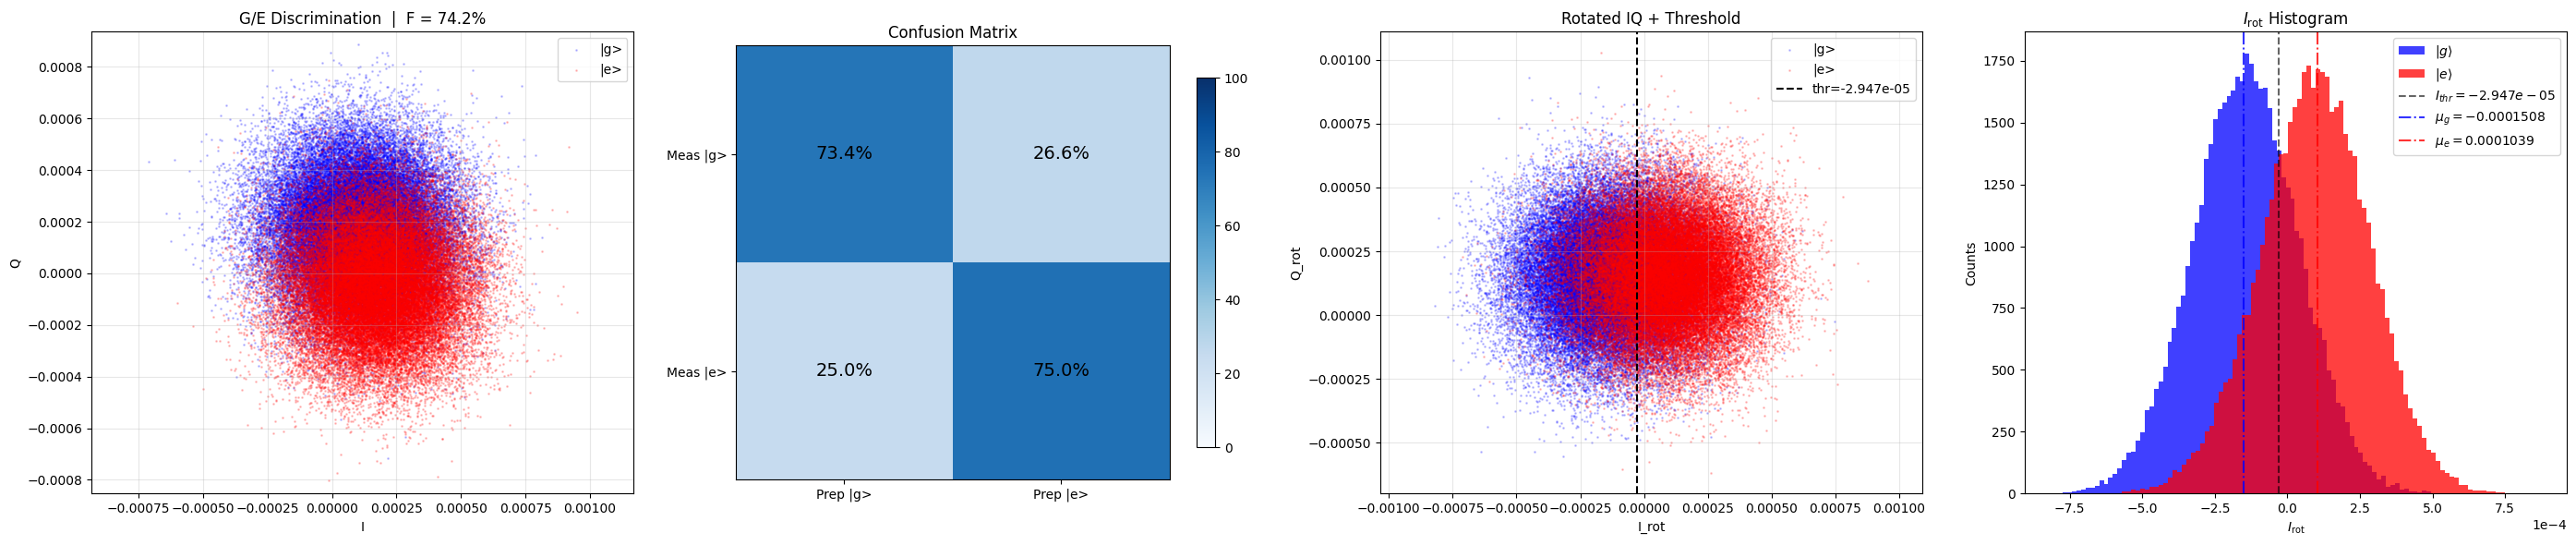

Fidelity = 7420.20%
Angle = 1.243 rad
Threshold = -0.0000

Resolved readout_ge mapping:
  element_readout: resonator
  operation:       readout
  pulse key:       readout_pulse
  base weights:    cos=readout_cosine_weights, sin=readout_sine_weights, m_sin=readout_minus_weights
Gaussianity (g) = 0.054
Gaussianity (e) = 0.191


In [ ]:
from qubox_v2.experiments.calibration.readout import ReadoutGEDiscrimination

ge = ReadoutGEDiscrimination(session)
result = ge.run(
    "readout",
    attr.ro_fq,
    r180="x180",
    n_samples=50000,
    update_measure_macro=True,
    apply_rotated_weights=True,
    persist=True,
)

analysis = ge.analyze(result, update_calibration=True)
ge.plot(analysis, show_rotated=True, interactive=False)
print(f"Fidelity = {analysis.metrics.get('fidelity', 0):.2f}%")
print(f"Angle = {analysis.metrics.get('angle', 0):.3f} rad")
print(f"Threshold = {analysis.metrics.get('threshold', 0):.4f}")

# Explicit mapping diagnostics
rp = getattr(ge, "_run_params", {})
print("\nResolved readout_ge mapping:")
print(f"  element_readout: {attr.ro_el}")
print(f"  operation:       {rp.get('measure_op')}")
print(f"  pulse key:       {getattr(rp.get('pulse_info', None), 'pulse', None)}")
print(f"  base weights:    cos={rp.get('base_cos_name')}, sin={rp.get('base_sin_name')}, m_sin={rp.get('base_m_sin_name')}")

# New diagnostics from the enhanced pipeline
if "gaussianity_g" in analysis.metrics:
    print(f"Gaussianity (g) = {analysis.metrics['gaussianity_g']:.3f}")
    print(f"Gaussianity (e) = {analysis.metrics['gaussianity_e']:.3f}")
if "cv_fidelity" in analysis.metrics:
    print(f"Cross-validated fidelity = {analysis.metrics['cv_fidelity']:.2%}")

### 6.3 Butterfly Measurement

Two successive measurements to quantify QND fidelity, F, Q, and V.

[INFO] 2026-02-22 17:56:56,973 qubox.experiments.calibration.readout: Butterfly measureMacro sync applied: element=resonator op=readout weights=['rot_cos', 'rot_sin', 'rot_m_sin']
[INFO] 2026-02-22 17:56:56,974 qubox.experiments.calibration.readout: Butterfly measurement: n_samples=50000, policy='BLOBS'
2026-02-22 17:56:57,159 - qm - INFO     - Sending program to QOP for compilation
2026-02-22 17:56:57,711 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 49999/50000 [00:03<00:00, 16333.48it/s]

[INFO] 2026-02-22 17:57:00,881 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622593016
No errors


[INFO] 2026-02-22 17:57:01,195 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-22 17:57:01,198 qubox.experiments.session: Output saved to E:\qubox\seq_1_device\data\butterflyMeasurement_20260222_175701.npz
[INFO] 2026-02-22 17:57:01,203 qubox.experiments.calibration.readout: Butterfly metrics: F=0.7182, Q=0.9729, V=0.4363, t01=0.0023, t10=0.0518
[WARNING] 2026-02-22 17:57:01,207 qubox.experiments.experiment_base: Calibration commit skipped for readout_butterfly. Artifact saved at E:\qubox\seq_1_device\artifacts\calibration_runs\readout_butterfly_20260222_175701.json. Errors: ['No fit object available']
[INFO] 2026-02-22 17:57:01,207 qubox.experiments.calibration.readout: measureMacro readout quality updated from butterfly analysis
[INFO] 2026-02-22 17:57:01,208 qubox.experiments.calibration.readout: T1 decay correction: readout=1600 ns, T1=19054941739.3 us, factor=1.0000
F = 71.82%
Q = 97.29%
V = 0.4363
t01 = 0.0023
t10 = 0.0518
Lambda_M_valid = True


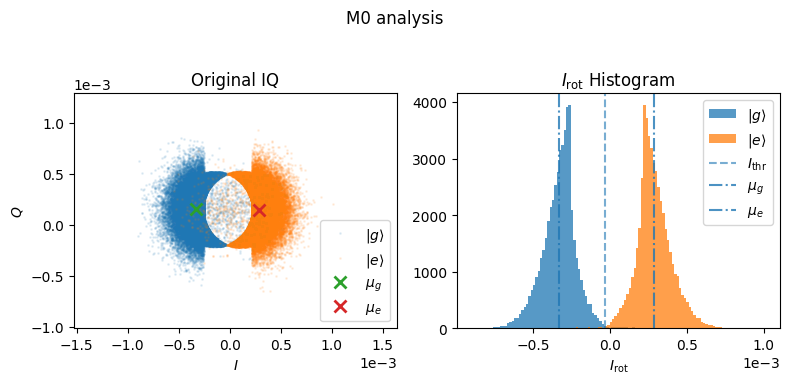

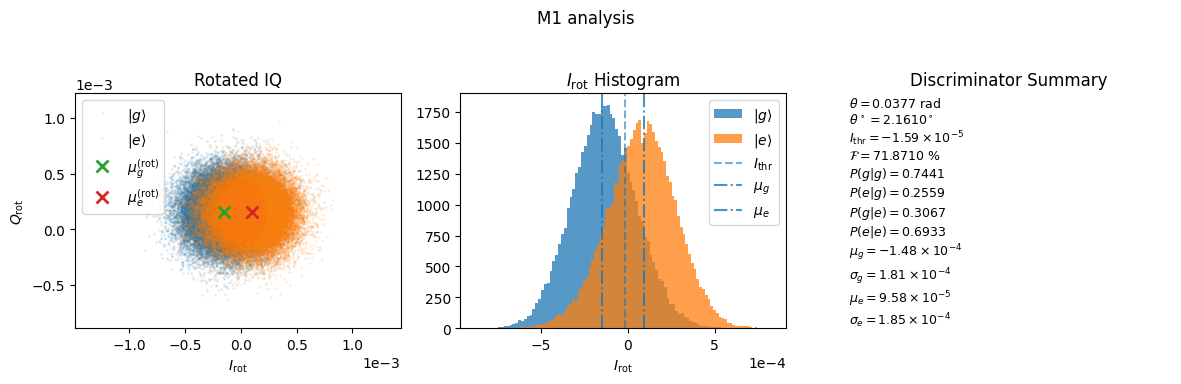

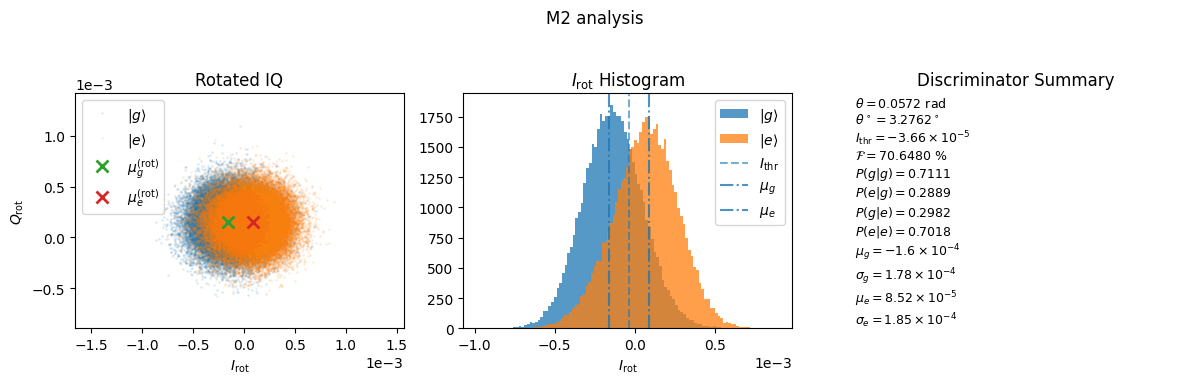

In [6]:
from qubox_v2.experiments.calibration.readout import ReadoutButterflyMeasurement

bfly = ReadoutButterflyMeasurement(session)
result = bfly.run(r180="x180", update_measure_macro=True, n_samples=50000)

analysis = bfly.analyze(result, update_calibration=True)
bfly.plot(analysis, show_histogram=True, show_discriminator=True)
print(f"F = {analysis.metrics.get('F', 0):.2%}")
print(f"Q = {analysis.metrics.get('Q', 0):.2%}")
print(f"V = {analysis.metrics.get('V', 0):.4f}")

# New diagnostics from the enhanced pipeline
if "t01" in analysis.metrics:
    print(f"t01 = {analysis.metrics['t01']:.4f}")
    print(f"t10 = {analysis.metrics['t10']:.4f}")
if "Lambda_M_valid" in analysis.metrics:
    print(f"Lambda_M_valid = {analysis.metrics['Lambda_M_valid']}")

### 6.4 Full Readout Calibration Pipeline

Automated pipeline: weights optimization -> GE discrimination -> butterfly.

In [ ]:
import importlib
import time
import numpy as np
import qubox_v2.experiments.calibration.readout as readout_mod
importlib.reload(readout_mod)

from qubox_v2.experiments.calibration.readout import (
    ReadoutWeightsOptimization,
    ReadoutGEDiscrimination,
    ReadoutButterflyMeasurement,
    CalibrateReadoutFull,
    ReadoutConfig,
 )
from qubox_v2.programs.macros.measure import measureMacro

# Legacy parity defaults from legacy calibrate_readout_full
LEGACY_BLOB_K = 3.0
LEGACY_M0_MAX_TRIALS = 1000

# --- Path controls ---
# Always check weight-optimization path for health/consistency.
RUN_WEIGHT_OPT_CHECK = True
WEIGHT_OPT_CHECK_N_AVG = 200_000

# Select which weights GE/Butterfly will use after the check.
# False -> base weights (legacy parity path you validated)
# True  -> optimized weights from check run
USE_OPTIMIZED_WEIGHTS_IN_PIPELINE = False

opt_cos_key, opt_sin_key, opt_m_sin_key = "cos", "sin", "minus_sin"
wopt_health = {
    "ran": False,
    "ok": False,
    "errors": [],
}

if RUN_WEIGHT_OPT_CHECK:
    try:
        t0 = time.perf_counter()
        wopt = ReadoutWeightsOptimization(session)
        wopt_result = wopt.run(
            ro_op="readout",
            drive_frequency=attr.ro_fq,
            cos_w_key="cos",
            sin_w_key="sin",
            m_sin_w_key="minus_sin",
            num_div=1,
            r180="x180",
            n_avg=WEIGHT_OPT_CHECK_N_AVG,
            persist=True,
            set_measure_macro=True,
        )
        wopt_analysis = wopt.analyze(wopt_result)
        dt = time.perf_counter() - t0

        # Extract keys/metrics
        opt_cos_key = wopt_analysis.metrics.get("opt_cos_key", "opt_cos")
        opt_sin_key = wopt_analysis.metrics.get("opt_sin_key", "opt_sin")
        opt_m_sin_key = wopt_analysis.metrics.get("opt_m_sin_key", "opt_minus_sin")
        ge_diff_norm_max = float(wopt_analysis.metrics.get("ge_diff_norm_max", float("nan")))
        trace_length = int(wopt_analysis.metrics.get("trace_length", -1))

        # Validate mapping exists on active readout pulse
        pulse_info = session.pulse_mgr.get_pulseOp_by_element_op(attr.ro_el, "readout", strict=False)
        mapping = (pulse_info.int_weights_mapping or {}) if pulse_info is not None else {}
        has_opt_map = all(k in mapping for k in (opt_cos_key, opt_sin_key, opt_m_sin_key))

        # Basic health checks
        checks = {
            "trace_length_positive": trace_length > 0,
            "ge_diff_norm_finite": np.isfinite(ge_diff_norm_max),
            "ge_diff_norm_nonzero": np.isfinite(ge_diff_norm_max) and ge_diff_norm_max > 0.0,
            "opt_mapping_present": has_opt_map,
        }
        failed = [name for name, ok in checks.items() if not ok]

        wopt_health.update({
            "ran": True,
            "ok": len(failed) == 0,
            "errors": failed,
            "elapsed_s": dt,
            "n_avg": WEIGHT_OPT_CHECK_N_AVG,
            "shots_per_s": (WEIGHT_OPT_CHECK_N_AVG / dt) if dt > 0 else float("nan"),
            "trace_length": trace_length,
            "ge_diff_norm_max": ge_diff_norm_max,
            "opt_keys": [opt_cos_key, opt_sin_key, opt_m_sin_key],
        })

        print("[Weight-Opt Check] completed")
        print(f"  elapsed_s        = {dt:.3f}")
        print(f"  shots_per_s      = {wopt_health['shots_per_s']:.1f}")
        print(f"  trace_length     = {trace_length}")
        print(f"  ge_diff_norm_max = {ge_diff_norm_max:.6f}")
        print(f"  opt_keys         = {opt_cos_key}, {opt_sin_key}, {opt_m_sin_key}")
        print(f"  status           = {'OK' if wopt_health['ok'] else 'FAIL'}")
        if failed:
            print(f"  failed_checks    = {failed}")

    except Exception as exc:
        wopt_health.update({
            "ran": True,
            "ok": False,
            "errors": [f"exception: {exc}"],
        })
        print("[Weight-Opt Check] FAILED with exception:", exc)

selected_keys = (opt_cos_key, opt_sin_key, opt_m_sin_key) if USE_OPTIMIZED_WEIGHTS_IN_PIPELINE else ("cos", "sin", "minus_sin")
print(f"[Pipeline] Weight mode for GE/Butterfly = {'optimized' if USE_OPTIMIZED_WEIGHTS_IN_PIPELINE else 'base'}")
print(f"[Pipeline] selected keys = {selected_keys}")

# D2) GE discrimination + rotated weights
ge = ReadoutGEDiscrimination(session)
ge_result = ge.run(
    "readout",
    attr.ro_fq,
    r180="x180",
    n_samples=50_000,
    base_weight_keys=selected_keys,
    update_measure_macro=True,
    apply_rotated_weights=True,
    persist=True,
    auto_update_postsel=True,
    blob_k_g=LEGACY_BLOB_K,
    blob_k_e=LEGACY_BLOB_K,
 )
ge_analysis = ge.analyze(ge_result, update_calibration=True)
rot_validation = ge.verify_rotated_weights()

# D3) Butterfly -> confusion matrix + transition matrix
bfly = ReadoutButterflyMeasurement(session)
bfly_result = bfly.run(
    r180="x180",
    update_measure_macro=True,
    n_samples=50_000,
    M0_MAX_TRIALS=LEGACY_M0_MAX_TRIALS,
 )
bfly_analysis = bfly.analyze(bfly_result, update_calibration=True)

bfly_acceptance = bfly_analysis.metrics.get("acceptance_rate", float("nan"))
bfly_avg_tries = bfly_analysis.metrics.get("average_tries", float("nan"))
bfly_lambda_valid = bfly_analysis.metrics.get("Lambda_M_valid", None)
ge_fid_pct = float(ge_analysis.metrics.get("fidelity", float("nan")))
ge_fid_frac = ge_fid_pct / 100.0 if ge_fid_pct == ge_fid_pct else float("nan")
bfly_F = float(bfly_analysis.metrics.get("F", float("nan")))
ge_minus_F = ge_fid_frac - bfly_F if (ge_fid_frac == ge_fid_frac and bfly_F == bfly_F) else float("nan")

ro_pipeline_summary = {
    "weights": {
        "mode": "optimized" if USE_OPTIMIZED_WEIGHTS_IN_PIPELINE else "base",
        "selected": list(selected_keys),
        "check": wopt_health,
        "rotated_valid": bool(rot_validation.get("all_valid", False)),
    },
    "discrimination": {
        "fidelity_pct": ge_fid_pct,
        "fidelity_frac": ge_fid_frac,
        "angle": ge_analysis.metrics.get("angle"),
        "threshold": ge_analysis.metrics.get("threshold"),
        "rot_mu_g": ge_analysis.metrics.get("rot_mu_g"),
        "rot_mu_e": ge_analysis.metrics.get("rot_mu_e"),
        "blob_k": LEGACY_BLOB_K,
    },
    "butterfly": {
        "F": bfly_F,
        "Q": bfly_analysis.metrics.get("Q"),
        "V": bfly_analysis.metrics.get("V"),
        "Lambda_M_valid": bfly_lambda_valid,
        "acceptance_rate": bfly_acceptance,
        "average_tries": bfly_avg_tries,
        "confusion_matrix": bfly_analysis.metrics.get("confusion_matrix"),
        "transition_matrix": bfly_analysis.metrics.get("transition_matrix"),
    },
    "parity": {
        "ge_minus_F": ge_minus_F,
        "abs_ge_minus_F": abs(ge_minus_F) if ge_minus_F == ge_minus_F else float("nan"),
    },
}

print("Readout calibration pipeline complete.")
print(f"Weight mode = {ro_pipeline_summary['weights']['mode']}")
print(f"Rotated weights valid: {rot_validation.get('all_valid', False)}")
print(f"GE fidelity = {ge_fid_pct:.2f}%  ({ge_fid_frac:.4f} frac)")
print(f"GE angle    = {ge_analysis.metrics.get('angle', 0):.6f} rad")
print(f"GE thr      = {ge_analysis.metrics.get('threshold', 0):.6g}")
print(f"F = {bfly_analysis.metrics.get('F', 0):.4f}, Q = {bfly_analysis.metrics.get('Q', 0):.4f}, V = {bfly_analysis.metrics.get('V', 0):.4f}")
print(f"GE/100 - F  = {ge_minus_F:.4f}")
print(f"Lambda_M_valid = {bfly_lambda_valid}")
print(f"acceptance_rate = {bfly_acceptance}")
print(f"average_tries   = {bfly_avg_tries}")
print(f"measureMacro confusion loaded: {measureMacro._ro_quality_params.get('confusion_matrix') is not None}")

cm = bfly_analysis.metrics.get("confusion_matrix", None)
tm = bfly_analysis.metrics.get("transition_matrix", None)
if cm is not None:
    print("\nButterfly confusion matrix Lambda_M:")
    try:
        print(cm.to_markdown(floatfmt=".4f"))
    except Exception:
        print(cm)
if tm is not None:
    print("\nButterfly transition matrix T:")
    try:
        print(tm.to_markdown(floatfmt=".4f"))
    except Exception:
        print(tm)

[Pipeline] Running WITHOUT weight optimization (using base cos/sin/minus_sin weights)
[INFO] 2026-02-22 18:17:16,162 qubox.experiments.calibration.readout: GE discrimination: n_samples=50000, measure_op='readout'
[INFO] 2026-02-22 18:17:16,201 qubox.experiments.calibration.readout: GE discrimination mapping: element=resonator op=readout pulse=readout_pulse available_ops=['const', 'readout']
2026-02-22 18:17:16,324 - qm - INFO     - Sending program to QOP for compilation
2026-02-22 18:17:16,395 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 49999/50000 [00:10<00:00, 4914.85it/s]

[INFO] 2026-02-22 18:17:26,636 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622593029
No errors


[INFO] 2026-02-22 18:17:26,715 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-22 18:17:28,491 qubox.experiments.calibration.readout: GE discrimination fidelity=74.41%, angle=1.2795 rad, threshold=-3.015e-05
[INFO] 2026-02-22 18:17:29,712 qubox.experiments.calibration.readout: measureMacro updated with rotated readout weights
[INFO] 2026-02-22 18:17:29,714 qubox.experiments.calibration.readout: Persisted measureMacro state to E:\qubox\seq_1_device\config\measureConfig.json
[INFO] 2026-02-22 18:17:29,715 qubox.experiments.calibration.readout: Rotated integration weights computed AND applied
[INFO] 2026-02-22 18:17:29,715 qubox.experiments.calibration.readout: Rotated weight verification: PASSED. Active weights: {'rot_cos': 'rot_cos', 'rot_sin': 'rot_sin', 'rot_m_sin': 'rot_m_sin'}
[INFO] 2026-02-22 18:17:29,715 qubox.experiments.calibration.readout: Rotated weights validation PASSED
[INFO] 2026-02-22 18:17:29,716 qubox.experiments.calibration.readout: Post-selecti

Running Program...: 100%|█████████▉| 49999/50000 [00:05<00:00, 9225.48it/s]

[INFO] 2026-02-22 18:17:36,004 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622593030
No errors


[INFO] 2026-02-22 18:17:36,332 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-22 18:17:36,335 qubox.experiments.session: Output saved to E:\qubox\seq_1_device\data\butterflyMeasurement_20260222_181736.npz
[INFO] 2026-02-22 18:17:36,340 qubox.experiments.calibration.readout: Butterfly metrics: F=0.7320, Q=0.9656, V=0.4639, t01=0.0059, t10=0.0629
[INFO] 2026-02-22 18:17:36,345 qubox.experiments.experiment_base: Calibration commit applied for readout_butterfly. Artifact saved at E:\qubox\seq_1_device\artifacts\calibration_runs\readout_butterfly_20260222_181736.json
[INFO] 2026-02-22 18:17:36,346 qubox.experiments.calibration.readout: measureMacro readout quality updated from butterfly analysis
[INFO] 2026-02-22 18:17:36,346 qubox.experiments.calibration.readout: T1 decay correction: readout=1600 ns, T1=19054941739.3 us, factor=1.0000
Readout calibration pipeline complete.
Weight mode = SKIPPED (base weights)
Selected keys: cos, sin, minus_sin
Rotated weights valid:

### 6.4b GE → Butterfly Parity Check (Legacy-Aligned)

Run standalone GE then standalone butterfly using the same `blob_k` and trial settings as Section 6.4.
This isolates orchestration effects and helps verify parity with legacy expectations.

In [5]:
# Reuse legacy-aligned settings from Section 6.4
PARITY_BLOB_K = LEGACY_BLOB_K
PARITY_M0_MAX_TRIALS = LEGACY_M0_MAX_TRIALS

# Keep keys consistent with Section 6.4 even when weight optimization is skipped
if "opt_cos_key" not in globals() or "opt_sin_key" not in globals() or "opt_m_sin_key" not in globals():
    opt_cos_key, opt_sin_key, opt_m_sin_key = "cos", "sin", "minus_sin"

ge_parity = ReadoutGEDiscrimination(session)
ge_parity_res = ge_parity.run(
    "readout",
    attr.ro_fq,
    r180="x180",
    n_samples=50_000,
    base_weight_keys=(opt_cos_key, opt_sin_key, opt_m_sin_key),
    update_measure_macro=True,
    apply_rotated_weights=True,
    persist=True,
    auto_update_postsel=True,
    blob_k_g=PARITY_BLOB_K,
    blob_k_e=PARITY_BLOB_K,
 )
ge_parity_an = ge_parity.analyze(ge_parity_res, update_calibration=False)

bfly_parity = ReadoutButterflyMeasurement(session)
bfly_parity_res = bfly_parity.run(
    r180="x180",
    update_measure_macro=True,
    n_samples=50_000,
    M0_MAX_TRIALS=PARITY_M0_MAX_TRIALS,
 )
bfly_parity_an = bfly_parity.analyze(bfly_parity_res, update_calibration=False)

ge_parity_pct = float(ge_parity_an.metrics.get("fidelity", float("nan")))
ge_parity_frac = ge_parity_pct / 100.0 if ge_parity_pct == ge_parity_pct else float("nan")
bfly_parity_F = float(bfly_parity_an.metrics.get("F", float("nan")))
delta_parity = ge_parity_frac - bfly_parity_F if (ge_parity_frac == ge_parity_frac and bfly_parity_F == bfly_parity_F) else float("nan")

print("=== Parity Check (Standalone GE -> Butterfly) ===")
print(f"GE fidelity = {ge_parity_pct:.2f}% ({ge_parity_frac:.4f} frac)")
print(f"GE angle    = {ge_parity_an.metrics.get('angle', 0):.6f} rad")
print(f"GE thr      = {ge_parity_an.metrics.get('threshold', 0):.6g}")
print(f"F = {bfly_parity_F:.4f}, Q = {bfly_parity_an.metrics.get('Q', 0):.4f}, V = {bfly_parity_an.metrics.get('V', 0):.4f}")
print(f"GE/100 - F  = {delta_parity:.4f}")
print(f"Lambda_M_valid = {bfly_parity_an.metrics.get('Lambda_M_valid', None)}")
print(f"acceptance_rate = {bfly_parity_an.metrics.get('acceptance_rate', float('nan'))}")
print(f"average_tries   = {bfly_parity_an.metrics.get('average_tries', float('nan'))}")

[INFO] 2026-02-22 18:17:36,364 qubox.experiments.calibration.readout: GE discrimination: n_samples=50000, measure_op='readout'
[INFO] 2026-02-22 18:17:36,401 qubox.experiments.calibration.readout: GE discrimination mapping: element=resonator op=readout pulse=readout_pulse available_ops=['const', 'readout']
2026-02-22 18:17:36,488 - qm - INFO     - Sending program to QOP for compilation
2026-02-22 18:17:36,555 - qm - INFO     - Executing program


Running Program...: 100%|█████████▉| 49999/50000 [00:10<00:00, 4925.49it/s]

[INFO] 2026-02-22 18:17:46,765 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622593031
No errors


[INFO] 2026-02-22 18:17:46,840 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-22 18:17:48,587 qubox.experiments.calibration.readout: GE discrimination fidelity=74.35%, angle=1.2709 rad, threshold=-1.938e-05
[INFO] 2026-02-22 18:17:50,161 qubox.experiments.calibration.readout: measureMacro updated with rotated readout weights
[INFO] 2026-02-22 18:17:50,163 qubox.experiments.calibration.readout: Persisted measureMacro state to E:\qubox\seq_1_device\config\measureConfig.json
[INFO] 2026-02-22 18:17:50,164 qubox.experiments.calibration.readout: Rotated integration weights computed AND applied
[INFO] 2026-02-22 18:17:50,164 qubox.experiments.calibration.readout: Rotated weight verification: PASSED. Active weights: {'rot_cos': 'rot_cos', 'rot_sin': 'rot_sin', 'rot_m_sin': 'rot_m_sin'}
[INFO] 2026-02-22 18:17:50,165 qubox.experiments.calibration.readout: Rotated weights validation PASSED
[INFO] 2026-02-22 18:17:50,165 qubox.experiments.calibration.readout: Post-selecti

Running Program...: 100%|█████████▉| 49999/50000 [00:05<00:00, 9302.91it/s]


[INFO] 2026-02-22 18:17:56,379 qubox.hardware.program_runner: Execution report:
Execution report for job 1771622593032
No errors
[INFO] 2026-02-22 18:17:56,712 qubox.hardware.program_runner: Job halted successfully.
[INFO] 2026-02-22 18:17:56,715 qubox.experiments.session: Output saved to E:\qubox\seq_1_device\data\butterflyMeasurement_20260222_181756.npz
[INFO] 2026-02-22 18:17:56,720 qubox.experiments.calibration.readout: Butterfly metrics: F=0.7287, Q=0.9623, V=0.4573, t01=0.0003, t10=0.0752
[INFO] 2026-02-22 18:17:56,721 qubox.experiments.calibration.readout: measureMacro readout quality updated from butterfly analysis
[INFO] 2026-02-22 18:17:56,721 qubox.experiments.calibration.readout: T1 decay correction: readout=1600 ns, T1=19054941739.3 us, factor=1.0000
=== Parity Check (Standalone GE -> Butterfly) ===
GE fidelity = 74.35% (0.7435 frac)
GE angle    = 1.270911 rad
GE thr      = -1.93772e-05
F = 0.7287, Q = 0.9623, V = 0.4573
GE/100 - F  = 0.0149
Lambda_M_valid = True
acceptanc

### 6.5 Standalone Readout Weight Optimization

Optimize integration weights using time-sliced g/e readout traces.
Computes the normalised `e - g` difference trace, builds segmented
integration weights (cos/sin/minus_sin triplet), and registers them
in the PulseOperationManager.

This is the same experiment run inside `CalibrateReadoutFull` Step 1,
exposed here for standalone use and debugging.

In [ ]:
wopt = ReadoutWeightsOptimization(session)
result = wopt.run(
    ro_op="readout",
    drive_frequency=attr.ro_fq,
    cos_w_key="cos",
    sin_w_key="sin",
    m_sin_w_key="minus_sin",
    num_div=1,
    r180="x180",
    n_avg=200_000,
    persist=True,
    set_measure_macro=True,
)

analysis = wopt.analyze(result)
wopt.plot(analysis)

print(f"trace_length     = {analysis.metrics.get('trace_length', 'N/A')}")
print(f"ge_diff_norm_max = {analysis.metrics.get('ge_diff_norm_max', 'N/A'):.4f}")
print(f"opt_cos_key      = {analysis.metrics.get('opt_cos_key', 'N/A')}")
print(f"opt_sin_key      = {analysis.metrics.get('opt_sin_key', 'N/A')}")
print(f"opt_m_sin_key    = {analysis.metrics.get('opt_m_sin_key', 'N/A')}")

### 6.6 Readout Calibration Artifacts

Save all readout calibration metrics and state machine histories as
session artifacts for reproducibility.

In [ ]:
import importlib
from pathlib import Path
import qubox_v2.experiments.calibration.gates as gates_mod
importlib.reload(gates_mod)
from qubox_v2.experiments.calibration.gates import AllXY
from qubox_v2.programs.macros.measure import measureMacro

# Persist readout + pulse calibration artifacts for fresh-session reload
session.calibration.save()
session.save_pulses()
measure_cfg_path = Path(experiment_path) / "config" / "measureConfig.json"
measure_cfg_path.parent.mkdir(parents=True, exist_ok=True)
measureMacro.save_json(str(measure_cfg_path))

# Reload measureMacro from disk to validate persistence path
measureMacro.load_json(str(measure_cfg_path))

# Run ALLXY with corrected sigma_z scaling
allxy = AllXY(session)
allxy_result = allxy.run(n_avg=5000)
allxy_analysis = allxy.analyze(allxy_result)
allxy.plot(allxy_analysis)

cm = measureMacro._ro_quality_params.get("confusion_matrix", None)
tm = measureMacro._ro_quality_params.get("transition_matrix", None)

print("=== Calibration Summary ===")
print(f"g_pi (ref_r180): {float(globals().get('rabi_g_pi', float('nan'))):.6f}")

primitive_ops = ["x180", "y180", "x90", "xn90", "y90", "yn90"]
print("Primitive pulse amplitudes:")
for op_name in primitive_ops:
    pcal = session.calibration.get_pulse_calibration(op_name)
    print(f"  {op_name:5s}: {getattr(pcal, 'amplitude', None)}")

if "ro_pipeline_summary" in globals():
    disc = ro_pipeline_summary["discrimination"]
    bfly = ro_pipeline_summary["butterfly"]
    print(f"Blob centers: mu_g={disc.get('rot_mu_g')}, mu_e={disc.get('rot_mu_e')}")
    print(f"Rotation angle: {disc.get('angle')}")
    print(f"F={bfly.get('F')}, Q={bfly.get('Q')}, V={bfly.get('V')}")

print("Confusion matrix:")
print(cm)
print("Transition matrix:")
print(tm)
print(f"ALLXY observable: {allxy_analysis.metrics.get('observable')}")
print(f"ALLXY correction applied: {allxy_analysis.metrics.get('used_confusion_correction')}")
print(f"ALLXY state mapping: {allxy_analysis.metrics.get('state_mapping')}")
print("Final mapping: +1 -> |g>, -1 -> |e>")
print(f"measureConfig persisted to: {measure_cfg_path}")

## 7. SPA Benchmarking

### 7.1 SPA Flux Optimization

Sweep DC flux bias with SPA-enhanced readout to find optimal flux point.

In [ ]:
spa_flux = SPAFluxOptimization(session)
result = spa_flux.run(
    dc_list=np.linspace(-0.5, 0.5, 51),
    sample_fqs=np.linspace(8.5e9, 8.7e9, 21),
    n_avg=1000,
)

analysis = spa_flux.analyze(result)
spa_flux.plot(analysis)
print(f"Best DC = {analysis.metrics.get('best_dc', 'N/A'):.4f} V")
print(f"Best freq = {analysis.metrics.get('best_freq', 0) / 1e6:.2f} MHz")

### 7.2 SPA Pump Frequency Optimization

2D sweep of pump power and detuning to optimize SPA readout fidelity.

In [ ]:
spa_pump = SPAPumpFrequencyOptimization(session)
# result = spa_pump.run(
#     readout_op="readout",
#     drive_frequency=attr.qb_fq,
#     pump_powers=np.linspace(0.1, 1.0, 10),
#     pump_detunings=np.linspace(-5e6, 5e6, 21),
#     r180="x180",
#     samples_per_run=25000,
# )
# analysis = spa_pump.analyze(result)
# spa_pump.plot(analysis)
# print(f"Best pump power = {analysis.metrics.get('best_pump_power', 'N/A')}")
# print(f"Best pump detuning = {analysis.metrics.get('best_pump_detuning', 'N/A')}")

## 8. Storage Cavity

### 8.1 Storage Spectroscopy

Sweep storage cavity frequency to locate resonance.

In [ ]:
st_spec = StorageSpectroscopy(session)
result = st_spec.run(
    disp="const_alpha",
    rf_begin=5200 * u.MHz,
    rf_end=5280 * u.MHz,
    df=200 * u.kHz,
    storage_therm_time=500,
    n_avg=50,
)

analysis = st_spec.analyze(result, update_calibration=True)
st_spec.plot(analysis)
print(f"f_storage = {analysis.metrics['f_storage'] / 1e6:.4f} MHz")
print(f"kappa = {analysis.metrics['kappa'] / 1e3:.1f} kHz")

### 8.2 Number Splitting Spectroscopy

Resolve photon-number-dependent qubit frequency shifts.

`state_prep` is now explicit (not auto-generated). Define it in the notebook and pass it to `run()`.

In [ ]:
from qm.qua import wait

def prep_vacuum():
    # Explicit no-op preparation for notebook-driven workflows
    wait(1)

nsplit = NumSplittingSpectroscopy(session)
result = nsplit.run(
    rf_centers=[attr.qb_fq],
    rf_spans=[10 * u.MHz],
    df=100 * u.kHz,
    state_prep=prep_vacuum,
    n_avg=500,
    # Temporary backward-compat path if needed: allow_default_state_prep=True,
 )

analysis = nsplit.analyze(result)
nsplit.plot(analysis)
print(analysis.metrics)

### 8.3 Storage Chi Ramsey

Measure dispersive coupling chi via Ramsey interferometry.

In [ ]:
# NOTE: StorageChiRamsey requires measureMacro to be configured.
# Run CalibrateReadoutFull (Section 6) before this cell.

chi_ramsey = StorageChiRamsey(session)
result = chi_ramsey.run(
    fock_fq=attr.qb_fq,
    delay_ticks=np.arange(4, 2000, 10),
    disp_pulse="const_alpha",
    x90_pulse="x90",
    n_avg=20,
)

# p0: [P0, A, T2_eff(ns), nbar, chi(1/ns), t0(ns)]
# T2_eff ~ 35 us = 35000 ns;  chi ~ 2.8 MHz = 0.0028/ns;  t0 ~ 0.4 us = 400 ns
analysis = chi_ramsey.analyze(result, update_calibration=True,
                              p0=[0.5, 0.5, 35000, 0.1, 0.0028, 400])
chi_ramsey.plot(analysis)
print(f"chi = {analysis.metrics.get('chi', 0) / 1e3:.1f} kHz")
print(f"nbar = {analysis.metrics.get('nbar', 0):.2f}")

### 8.4 Fock-Resolved Spectroscopy

Probe qubit spectroscopy conditioned on Fock number.

In [ ]:
fock_spec = FockResolvedSpectroscopy(session)
result = fock_spec.run(
    probe_fqs=np.linspace(attr.qb_fq - 5e6, attr.qb_fq + 5e6, 101),
    state_prep=prep_vacuum,
    n_avg=20,
    # Temporary backward-compat path if needed: allow_default_state_prep=True,
 )

analysis = fock_spec.analyze(result)
fock_spec.plot(analysis)
print(analysis.metrics)

### 8.4b Register Displacement Pulses for Fock-Resolved Experiments

**REQUIRED** before running Fock-resolved T1, Ramsey, or Power Rabi.
This generates `disp_n0`, `disp_n1`, etc. on the storage element and burns them into the QM config.

In [ ]:
from qubox_v2.tools.generators import ensure_displacement_ops

# Number of Fock manifolds to prepare displacement pulses for
n_fock = 3

# Prefer session runtime settings (migrated ownership); fallback is handled in SessionManager
disp_ref = session.get_displacement_reference()
coherent_amp = disp_ref.get("coherent_amp", None)
coherent_len = disp_ref.get("coherent_len", None)
b_alpha = disp_ref.get("b_alpha", None)

# Generate displacement pulses using calibrated storage parameters
created = ensure_displacement_ops(
    session.pulse_mgr,
    element=attr.st_el,
    n_max=n_fock,
    coherent_amp=coherent_amp,
    coherent_len=coherent_len,
    b_alpha=b_alpha,
 )

# Burn into QM config so hardware programs can use them
session.burn_pulses()

print(f"Displacement refs: amp={coherent_amp}, len={coherent_len}, alpha={b_alpha}")
print(f"Registered {len(created)} displacement ops on '{attr.st_el}':")
for name, (I, Q) in created.items():
    print(f"  {name}: len={len(I)}, max_I={I.max():.4f}, max_Q={Q.max():.4f}")

### 8.5 Fock-Resolved T1

Measure T1 in individual Fock manifolds.

In [ ]:
fock_t1 = FockResolvedT1(session)

# fock_fqs defaults to attr.fock_fqs from cqed_params.json when not provided.
# To use a subset: fock_fqs = attr.get_fock_frequencies(2)
n_fock = 2
fock_fqs = attr.get_fock_frequencies(n_fock)
result = fock_t1.run(
     fock_fqs=fock_fqs,
     fock_disps=["disp_n0", "disp_n1"],
     delay_end=40000,
     dt=200,
     n_avg=20,
)
analysis = fock_t1.analyze(result)
fock_t1.plot(analysis)
for key, val in analysis.metrics.items():
     if key.startswith("T1_fock_"):
         print(f"{key} = {val / 1e3:.2f} us")

### 8.6 Fock-Resolved Ramsey

Measure T2 in individual Fock manifolds.

In [ ]:
fock_ramsey = FockResolvedRamsey(session)

# fock_fqs defaults to attr.fock_fqs from cqed_params.json when not provided.
n_fock = 2
fock_fqs = attr.get_fock_frequencies(n_fock)
result = fock_ramsey.run(
     fock_fqs=fock_fqs,
     detunings=[0.2e6],
     disps=["disp_n0", "disp_n1"],
     delay_end=40000,
     dt=100,
     n_avg=20,
)
analysis = fock_ramsey.analyze(result)
fock_ramsey.plot(analysis)
print(analysis.metrics)

### 8.7 Fock-Resolved Power Rabi

Calibrate selective pi pulses per Fock manifold.

In [ ]:
fock_rabi = FockResolvedPowerRabi(session)
# fock_fqs = [...]  # From NumSplittingSpectroscopy results
# result = fock_rabi.run(
#     fock_fqs=fock_fqs,
#     gains=np.linspace(0, 1.5, 50),
#     sel_qb_pulse="sel_x180",
#     disp_n_list=["disp_n0", "disp_n1", "disp_n2"],
#     n_avg=2000,
# )
# analysis = fock_rabi.analyze(result)
# fock_rabi.plot(analysis)
# for key, val in analysis.metrics.items():
#     if key.startswith("g_pi_fock_"):
#         print(f"{key} = {val:.4f}")

## 9. Quantum State Tomography

### 9.1 Qubit State Tomography

Three-axis measurement (sigma_x, sigma_y, sigma_z) to reconstruct
the qubit Bloch vector.

In [ ]:
from qm.qua import *

def prep_x_plus():
    """Prepare |+x> state."""
    play("x90", attr.qb_el)

tomo = QubitStateTomography(session)
result = tomo.run(
    state_prep=prep_x_plus,
    n_avg=10000,
)

analysis = tomo.analyze(result)
tomo.plot(analysis)
print(f"sx = {analysis.metrics.get('sx', 0):.3f}")
print(f"sy = {analysis.metrics.get('sy', 0):.3f}")
print(f"sz = {analysis.metrics.get('sz', 0):.3f}")
print(f"Purity = {analysis.metrics.get('purity', 0):.3f}")

### 9.2 Wigner Tomography

Reconstruct the Wigner function of the storage cavity state.

In [ ]:
wigner = StorageWignerTomography(session)
# Requires gate sequence for state preparation
# result = wigner.run(
#     gates=[...],
#     x_vals=np.linspace(-3, 3, 41),
#     p_vals=np.linspace(-3, 3, 41),
#     n_avg=500,
# )
# analysis = wigner.analyze(result)
# wigner.plot(analysis)
# print(f"W_min = {analysis.metrics.get('W_min', 0):.3f}")
# print(f"W_max = {analysis.metrics.get('W_max', 0):.3f}")
# print(f"Negativity = {analysis.metrics.get('negativity', 0):.3f}")

### 9.3 SNAP Optimization

Optimize SNAP gate angles using Fock-resolved state tomography.

In [ ]:
snap = SNAPOptimization(session)
# result = snap.run(
#     snap_gate=...,
#     disp1_gate=...,
#     fock_probe_fqs=[...],
#     n_avg=500,
# )
# analysis = snap.analyze(result)
# snap.plot(analysis)
# print(analysis.metrics)

## 9b. Session Verification & Summary

Run waveform regression checks, finalize session artifacts, and produce
a summary of all calibrations committed during this session.

### 9b.1 Waveform Regression Check

Verify that PulseFactory produces deterministic, correct waveforms for all
supported pulse shapes. Any failure here indicates a regression in the
waveform generation code.

In [ ]:
from qubox_v2.verification.waveform_regression import run_all_checks

wf_results = run_all_checks()
passed = sum(1 for r in wf_results if r.passed)
total = len(wf_results)
print(f"Waveform regression: {passed}/{total} passed")

for r in wf_results:
    if not r.passed:
        print(r)

if passed == total:
    print("All waveform regression checks PASSED.")
else:
    print(f"WARNING: {total - passed} waveform regression check(s) failed.")

### 9b.2 Session Summary & Artifact Finalization

Print build hash, all calibrations committed, key metrics, and save the
final session report via ArtifactManager.

In [ ]:
import datetime

print("=" * 60)
print("  SESSION SUMMARY")
print("=" * 60)
print(f"  Build hash:     {ss.build_hash}")
print(f"  Git commit:     {ss.git_commit or 'unknown'}")
print(f"  Timestamp:      {ss.build_timestamp}")
print()

# Collect calibration state machines
all_sms = []
for name in ["sm_rabi", "sm_drag", "sm_readout"]:
    try:
        sm_obj = eval(name)
        info = sm_obj.summary()
        all_sms.append(info)
        state_str = info["state"]
        committed = state_str == "committed"
        print(f"  {info['experiment']:20s}  {state_str:20s}  "
              f"{'COMMITTED' if committed else 'not committed'}")
    except NameError:
        pass

# Waveform regression
print(f"\n  Waveform regression:  {passed}/{total} passed")

# Schema validation
n_valid = sum(1 for r in schema_results if r.valid)
print(f"  Schema validation:    {n_valid}/{len(schema_results)} passed")

print()

# Save session summary report
report_lines = [
    f"# Session Report",
    f"",
    f"- Build hash: {ss.build_hash}",
    f"- Git commit: {ss.git_commit or 'unknown'}",
    f"- Timestamp:  {ss.build_timestamp}",
    f"- Report generated: {datetime.datetime.now().isoformat()}",
    f"",
    f"## Calibration State Machines",
    f"",
]
for info in all_sms:
    report_lines.append(f"- **{info['experiment']}**: {info['state']} "
                        f"({info['transitions']} transitions, "
                        f"has_patch={info['has_patch']})")
report_lines += [
    f"",
    f"## Verification",
    f"",
    f"- Waveform regression: {passed}/{total} passed",
    f"- Schema validation: {n_valid}/{len(schema_results)} passed",
]

am.save_report("session_summary", "\n".join(report_lines))

# List all artifacts
print("Artifacts:")
for artifact in am.list_artifacts():
    if artifact.is_file():
        print(f"  {artifact.relative_to(am.root)}")

print()
print("=" * 60)
from qubox_v2.core.artifact_manager import cleanup_artifacts
removed = cleanup_artifacts(experiment_path, keep_latest=5, current_hash=ss.build_hash)
if removed:
    print(f"  Cleaned up {len(removed)} old artifact directories.")
print("  Done.")

## 10. Utility: Continuous-Wave Output

Drive a target element continuously (infinite loop) for diagnostics such as
spectrum analyser alignment or mixer leakage checks. The program runs
indefinitely until manually halted via `job.halt()`.

In [ ]:
from qubox_v2.programs import cQED_programs

# --- CW parameters ---
target_element = attr.qb_el       # element to drive
cw_pulse = "const_x180"           # pulse operation to repeat
cw_gain = 0.5                     # amplitude scaling (0.0 to 1.0)
truncate_clks = 250               # truncate pulse length in clock cycles (1 clk = 4 ns)

# --- Build the infinite-loop program ---
cw_prog = cQED_programs.continuous_wave(
    target_el=target_element,
    pulse=cw_pulse,
    gain=cw_gain,
    truncate_clks=truncate_clks,
)

print(f"Starting CW output on '{target_element}'")
print(f"  pulse      = {cw_pulse}")
print(f"  gain       = {cw_gain}")
print(f"  truncate   = {truncate_clks} clks ({truncate_clks * 4} ns)")
print(f"  This program runs in an INFINITE LOOP.")
print(f"  To stop:  job.halt()")

# Execute directly on the quantum machine
job = session.hw.qm.execute(cw_prog)
print(f"\nJob started: {job.id}")
print("Run 'job.halt()' in the next cell to stop.")

In [ ]:
# --- Stop CW output ---
job.halt()
print("CW output halted.")

---

## Summary

All experiment classes follow the unified `run() -> analyze() -> plot()` protocol:

```python
exp = ExperimentClass(session)
result = exp.run(...)                              # Execute on hardware
analysis = exp.analyze(result, update_calibration=True)  # Fit + extract metrics
exp.plot(analysis)                                 # Visualize
print(analysis.metrics)                            # Inspect extracted parameters
```

Use `update_calibration=True` to automatically persist calibration results
to the `CalibrationStore`.

### Declarative Architecture Integration

This notebook integrates the **qubox_v2 declarative architecture** at key workflow points:

| Component | Where | Purpose |
|---|---|---|
| `SessionState` | Section 1.0b | Immutable config snapshot with SHA-256 build hash |
| `validate_config_dir` | Section 1.1 | Schema validation of all config files |
| `ArtifactManager` | Section 1.0b | Build-hash keyed artifact storage |
| `CalibrationStateMachine` | Sections 4.2b, 5.1b, 6.4 | Lifecycle enforcement for calibration commits |
| `CalibrationPatch` | Sections 4.2b, 5.1b, 6.4 | Explicit diff objects with quality gates |
| `PulseFactory` | Section 4.7b | Cross-check imperative vs declarative pulse compilation |
| `run_all_checks` | Section 9b.1 | Waveform regression verification |

Every calibration commit is tracked through a state machine lifecycle
(`IDLE -> CONFIGURED -> ACQUIRING -> ACQUIRED -> ANALYZING -> ANALYZED -> PENDING_APPROVAL -> COMMITTED`)
with explicit patches, validation gates, and artifact persistence for full audit trail.